In [1]:
# Imports
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from models import build_generator, build_discriminator, concatenate_data_label, to_categorical
from data_loader import CB2DataLoader
from properties import calc_metrics


2025-09-12 15:46:40.806691: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-12 15:46:41.007501: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [ ]:
# Config + load mask
config = {
    'active_path': 'data/cb2_active.csv',
    'inactive_path': 'data/cb2_inactive.csv',
    'mask_path': 'data/cb2maccsi.csv',
    'latent_dim': 100,
    'fingerprint_dim': 168,
    'batch_size': 32,
    'epochs': 10,              # shorter training for demo
    'g_lr': 0.0001,
    'd_lr': 0.000001,
    'sample_interval': 10,
    'checkpoint_dir': 'models'
}

os.makedirs(config['checkpoint_dir'], exist_ok=True)
os.makedirs("outputs", exist_ok=True)

# load MCS mask
MCS = pd.read_csv(config['mask_path'], header=None, sep='\s+')
MCS = MCS.set_index(MCS.columns[0])
MCS_index = [i for i in MCS.columns if MCS.loc['structurei', i] == 1] #change 'structurei' to your own index name

umask = np.ones((168,1), dtype=np.float32)
mask = np.zeros((168,1), dtype=np.float32)
for i in (np.array(MCS_index)-1):
    umask[i,0] = 0
    mask[i,0] = 1


In [5]:
# Prepare dataset
data_loader = CB2DataLoader(config['active_path'], config['inactive_path'])
dataset = data_loader.get_dataset(config['batch_size'])
print("Dataset loaded:", data_loader.x.shape)


2025-09-12 15:48:53.296043: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:966] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-09-12 15:48:53.327955: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:966] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-09-12 15:48:53.328006: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:966] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-09-12 15:48:53.329751: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild Tens

Dataset loaded: (4892, 168, 1)


In [ ]:
# Build models
generator = build_generator(config['latent_dim'], umask=umask, mask=mask)
discriminator = build_discriminator(config['fingerprint_dim'])

g_optimizer = tf.keras.optimizers.Adam(config['g_lr'], beta_1=0.5, beta_2=0.999)
d_optimizer = tf.keras.optimizers.Adam(config['d_lr'], beta_1=0.5, beta_2=0.999)
loss_fn = tf.keras.losses.BinaryCrossentropy()


In [7]:
# Define one training step
@tf.function
def train_step(real_data, labels):
    batch_size = tf.shape(real_data)[0]
    noise_z = tf.random.normal([batch_size, 1, config['latent_dim']])
    labels_one_hot = to_categorical(labels)
    labels_one_hot = tf.expand_dims(labels_one_hot, axis=1)

    noise_with_condition = tf.concat([noise_z, labels_one_hot], axis=2)
    noise_with_condition = tf.reshape(noise_with_condition, [batch_size, -1])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        fake_data = generator(noise_with_condition, training=True)

        real_conditional = concatenate_data_label(real_data, labels)
        fake_conditional = concatenate_data_label(fake_data, labels)

        real_output = discriminator(real_conditional, training=True)
        fake_output = discriminator(fake_conditional, training=True)

        real_loss = loss_fn(tf.ones_like(real_output), real_output)
        fake_loss = loss_fn(tf.zeros_like(fake_output), fake_output)
        d_loss = real_loss + fake_loss

        g_loss = loss_fn(tf.ones_like(fake_output), fake_output)

    gradients = disc_tape.gradient(d_loss, discriminator.trainable_variables)
    d_optimizer.apply_gradients(zip(gradients, discriminator.trainable_variables))

    gradients = gen_tape.gradient(g_loss, generator.trainable_variables)
    g_optimizer.apply_gradients(zip(gradients, generator.trainable_variables))

    return d_loss, g_loss


2025-09-12 15:50:11.597508: I tensorflow/stream_executor/cuda/cuda_blas.cc:1614] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.
2025-09-12 15:50:11.818039: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8401


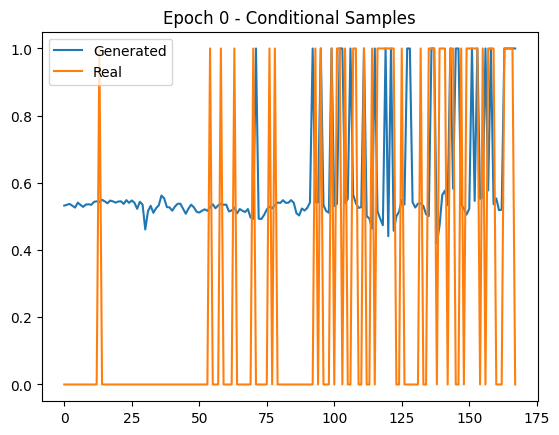

Epoch 0: D Loss: 1.3841, G Loss: 0.7030
Epoch 1: D Loss: 1.3840, G Loss: 0.6987


KeyboardInterrupt: 

In [8]:
# Training loop (short demo)
for epoch in range(config['epochs']):
    for real_data, labels in dataset:
        d_loss, g_loss = train_step(real_data, labels)
    if epoch % config['sample_interval'] == 0:
        noise = tf.random.normal([1, config['latent_dim']], dtype=tf.float32)
        target_one_hot = to_categorical(1)
        noise_with_condition = tf.concat([noise, target_one_hot], axis=1)
        sample = generator(noise_with_condition, training=False)

        plt.plot(sample.numpy().reshape(-1), label='Generated')
        plt.plot(data_loader.x[0,:,0], label='Real')
        plt.legend()
        plt.title(f"Epoch {epoch} - Conditional Samples")
        plt.show()
    print(f"Epoch {epoch}: D Loss: {d_loss:.4f}, G Loss: {g_loss:.4f}")


In [ ]:
# Save trained generator
generator.save_weights(f"{config['checkpoint_dir']}/generator_final.h5")
print("Model saved.")


In [9]:
# Load pre-trained generator
latent_dim = config['latent_dim']
num_classes = 2
gen = build_generator(latent_dim, num_classes, umask=umask, mask=mask)
gen.load_weights('./bestmodel/saved_best_model.h5')
print("Pre-trained model loaded.")


Pre-trained model loaded.


In [10]:
# Generate conditional samples (label=1, active)
num_samples = 1000
noise = tf.random.normal([num_samples, latent_dim])
target_labels = tf.constant([1] * num_samples)
target_one_hot = to_categorical(target_labels)
noise_with_condition = tf.concat([noise, target_one_hot], axis=1)

sample = gen(noise_with_condition, training=False)
generated = tf.reshape(sample, [num_samples, -1]).numpy()
print("Generated shape:", generated.shape)

pd.DataFrame(np.round(generated)).head()


Generated shape: (1000, 168)


,0,1,2,3,4,5,6,7,8,9,...,158,159,160,161,162,163,164,165,166,167
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0


In [ ]:
# Evaluate generated samples
real_data = data_loader.x[data_loader.y[:, 0] == 1].reshape(-1, 168)
metrics = calc_metrics(generated, real_data)

print("Evaluation Results:")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")


In [ ]:
# Save generated results
output_file = 'outputs/generated_samples.csv'
pd.DataFrame(np.round(generated)).to_csv(output_file, index=False)
print(f"Generated samples saved to {output_file}")
